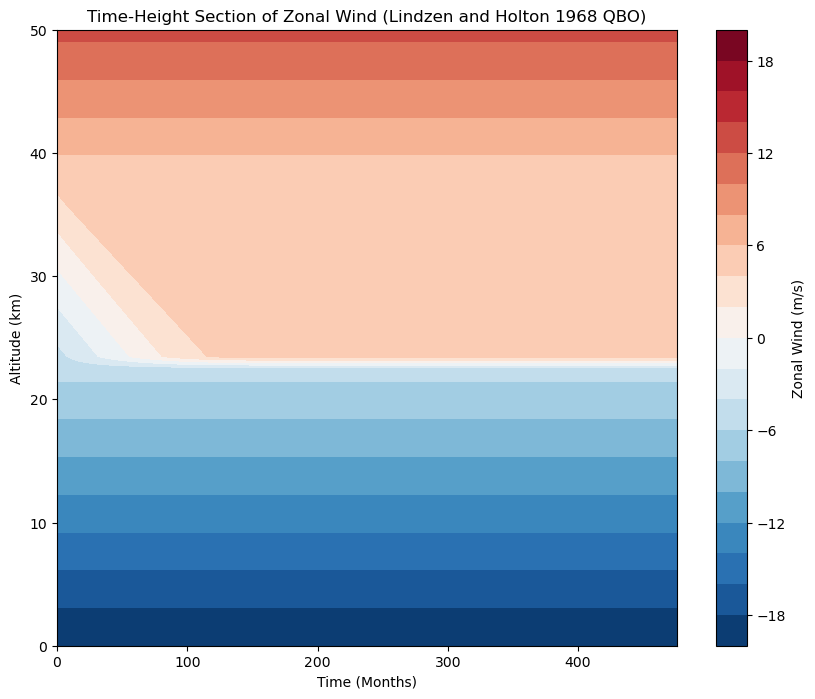

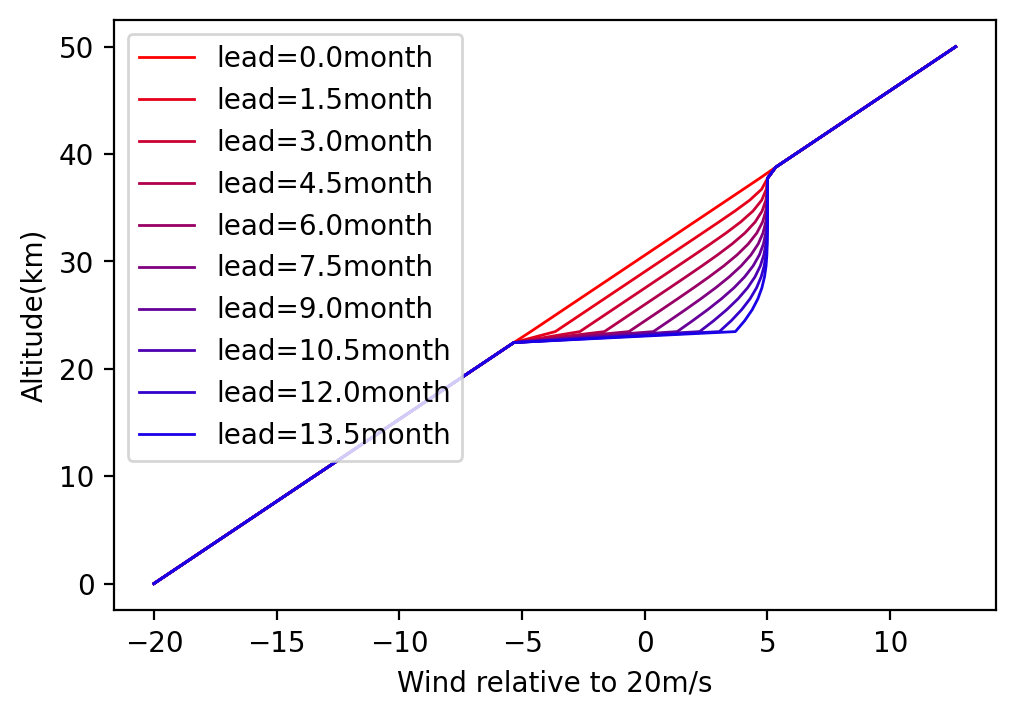

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Model parameters
z_levels = 50               # Number of vertical levels
dz = 1000                   # Vertical spacing (1 km in meters)
dt = 86400                  # Time step in seconds (1 day)
time_steps = 30*12*5        # Total time steps for 3 years

# Initial conditions
A = -20                     # Initial zonal wind offset (m/s)
B = 2 / 3                   # Gradient of initial zonal wind (m/s per km)
c_r = 5                     # Phase speed cutoff (m/s)
rho_0 = 1.2                              # Reference density (kg/m^3)
f_const = -rho_0 * 1000/86400/30         # Factor for f(U), as per paper

# Initialize arrays for mean zonal wind and height
U = A + B * np.arange(z_levels) * dz / 1000  # Initial zonal wind profile
output_intervals = []       # Store wind profiles for each time interval

# Define wave forcing function f(U) based on Lindzen and Holton (1968)
def wave_forcing(U, c_r, f_const):
    f_U  = np.zeros_like(U)
    mask = (np.abs(U) < c_r)  # Condition -cr < U < cr
    f_U[mask] = f_const       # Apply constant value for -cr < U < cr
    return f_U

# Time integration loop
for t in range(time_steps):
    # Calculate wave forcing f(U) for the current U profile
    f_U = wave_forcing(U, c_r, f_const)
    
    # Update the mean zonal wind profile
    for k in range(1, z_levels - 1):
        dU_dz = (U[k+1] - U[k]) / (dz)  # Central difference for dU/dz
        U[k] += dt * (-f_U[k] * dU_dz / rho_0)  # Update U based on Eq. (14)

    # Store results every 4 months (about 120 days)
    if t % 15 == 0:
        output_intervals.append(U.copy())

# Convert to a 2D array for plotting
zonal_wind_time_height = np.array(output_intervals)
time     = np.arange(0, len(output_intervals) * 4, 4)  # Time in months
altitude = np.linspace(0, z_levels * dz, z_levels) / 1000  # Altitude in km

# Plotting the time-height section of the zonal wind
plt.figure(figsize=(10, 8))
plt.contourf(time, altitude, zonal_wind_time_height.T, levels=np.linspace(-20, 20, 21), cmap='RdBu_r')
plt.colorbar(label='Zonal Wind (m/s)')
plt.xlabel('Time (Months)')
plt.ylabel('Altitude (km)')
plt.title('Time-Height Section of Zonal Wind (Lindzen and Holton 1968 QBO)')
plt.show()


def colorFader(c1,c2,mix=0): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    c1=np.array(mpl.colors.to_rgb(c1))
    c2=np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1-mix)*c1 + mix*c2)


# plt.figure(figsize=(10, 8))
# for i in range(0,120,4):
#     #print(i)
#     plt.plot(zonal_wind_time_height[i,:],altitude)
# #plt.colorbar(label='Zonal Wind (m/s)')
# #plt.xlabel('Time (Months)')
# plt.ylabel('Altitude (km)')
# plt.xlim([-10,10])
# plt.title('Time-Height Section of Zonal Wind (Lindzen and Holton 1968 QBO)')
# plt.show()

mm = 1/25.4  # millimeters in inches
fig = plt.figure(figsize=(2*70*mm,2*50*mm), dpi=200)  # create a figure object
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.15)
ax = fig.add_subplot(1, 1, 1)  # create an axes object in the figure

def colorFader(c1,c2,mix=0): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    c1=np.array(mpl.colors.to_rgb(c1))
    c2=np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1-mix)*c1 + mix*c2)

c1='red' #blue
c2='blue' #green
n = 30
x = np.linspace(0,3*np.pi,100)

for i in range(0,n,3):
    #ax.plot(x,i*np.sin(x),color=colorFader(c1,c2,i/n),linewidth = 1)
    ax.plot(zonal_wind_time_height[i,:],altitude,color=colorFader(c1,c2,i/n),linewidth = 1,label='lead='+str(i*0.5)+'month')
ax.legend()
ax.set_xlabel('Wind relative to 20m/s')
ax.set_ylabel('Altitude(km)')
fig.savefig('QBO_model.png')

In [69]:
!pwd

/Users/kaichiht/Library/CloudStorage/GoogleDrive-kuiper2000@gmail.com/.shortcut-targets-by-id/1uVpeHK5_xP9R6OFiq9ScJpGweQg4aL3c/tropical-dynamics-figures
